# Pareto Frontier

In [70]:
import numpy as np

def find_pareto_efficient_optimized(objectives: np.ndarray, return_mask: bool = True):
    """
    Finds the Pareto-efficient points (assuming maximization for all objectives).

    This optimized algorithm iteratively filters out dominated points. It starts
    with all points as candidates and, in each step, picks a candidate and
    removes all other points that are dominated by it.

    Args:
        objectives: An (n_points, n_objectives) NumPy array where each row represents
                  a point and each column represents an objective score to be maximized.
        return_mask: If True (default), returns a boolean mask indicating which of the
                     original points are Pareto efficient. If False, returns an array
                     of the integer indices of the efficient points.

    Returns:
        A boolean array (mask) of shape (n_points,) if return_mask is True,
        or an integer array of indices of the efficient points if return_mask is False.
    """
    num_points = objectives.shape[0]
    # Initially, all indices are candidates for the Pareto front.
    candidate_indices = np.arange(num_points)
    # Copy the objectives array to filter it in place without modifying the original.
    current_objectives = objectives.copy()
    # Index within the *current* filtered candidate_indices and current_objectives arrays
    # pointing to the next point to use for comparison.
    next_comparison_idx = 0

    # Loop while there are still points whose dominance needs to be checked.
    while next_comparison_idx < len(current_objectives):
        # Select the objective values of the current point being compared against.
        comparison_point_objectives = current_objectives[next_comparison_idx]

        # --- Identify points dominated by the comparison_point ---
        # (Maximization context)
        # A point `p` is dominated by `comparison_point` if *all* objectives of `p`
        # are less than or equal to the corresponding objectives of `comparison_point`,
        # AND at least one objective is strictly less.
        # It's computationally easier to find the *non-dominated* points.
        # A point `p` is NOT dominated by `comparison_point` if *any* objective of `p`
        # is strictly greater than the corresponding objective of `comparison_point`.

        # Find all points `p` where at least one objective is strictly better (higher).
        # `current_objectives > comparison_point_objectives` performs element-wise comparison.
        # `axis=1` checks if *any* objective is better along each row (point).
        is_not_dominated_mask = np.any(current_objectives > comparison_point_objectives, axis=1) # Changed < to >

        # The comparison point itself is never dominated by itself, so ensure it's kept.
        is_not_dominated_mask[next_comparison_idx] = True

        # --- Filter the candidates ---
        # Keep only the indices of points that were not dominated by the comparison point.
        candidate_indices = candidate_indices[is_not_dominated_mask]
        # Keep only the objective values of the non-dominated points for the next iteration.
        current_objectives = current_objectives[is_not_dominated_mask]

        # --- Update the index for the next comparison point ---
        # The `next_comparison_idx` needs to refer to the point *after* the one we just
        # processed, but its position might have shifted due to filtering.
        # We calculate how many points *before* the current `next_comparison_idx`
        # survived the filtering (`np.sum(is_not_dominated_mask[:next_comparison_idx])`)
        # and add 1 to point to the next element in the *filtered* array.
        next_comparison_idx = np.sum(is_not_dominated_mask[:next_comparison_idx]) + 1

    # --- Prepare the final output ---
    if return_mask:
        # Create a boolean mask of the original size, initially all False.
        pareto_mask = np.zeros(num_points, dtype=bool)
        # Set True for the indices that survived the filtering process.
        pareto_mask[candidate_indices] = True
        return pareto_mask
    else:
        # Return the array of indices of the Pareto-efficient points.
        return candidate_indices


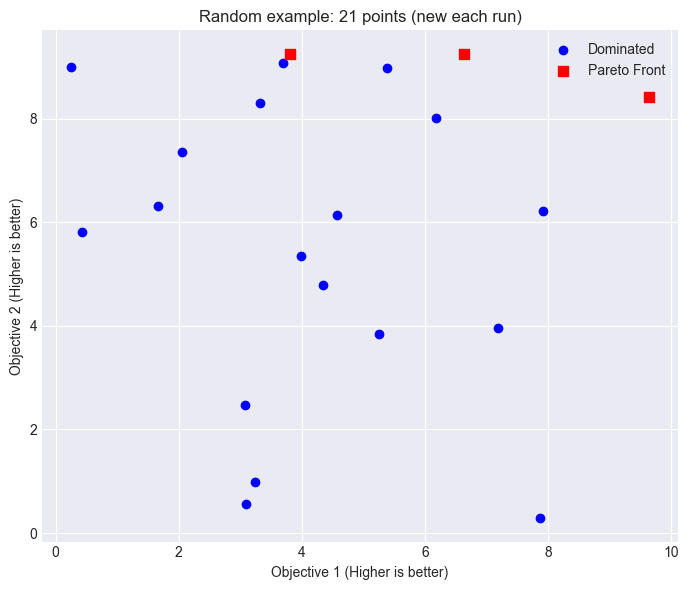

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Generate a random example each run (use a deterministic seed by setting `seed` if desired)
rng = np.random.default_rng()  # different each run by default
# number of points (random between 8 and 24)
n_points = int(rng.integers(8, 25))
# sample two objectives in [0, 10) to be maximized
objectives = rng.uniform(low=0.0, high=10.0, size=(n_points, 2))

# Compute Pareto-efficient mask using the function defined above
pareto_mask = find_pareto_efficient_optimized(objectives, return_mask=True)
pareto_points = objectives[pareto_mask]
dominated_points = objectives[~pareto_mask]

# --- Plotting ---
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(7, 6))

if dominated_points.size > 0:
    ax.scatter(dominated_points[:, 0], dominated_points[:, 1], c='blue', label='Dominated')
if pareto_points.size > 0:
    ax.scatter(pareto_points[:, 0], pareto_points[:, 1], c='red', marker='s', s=50, label='Pareto Front')

ax.set_xlabel("Objective 1 (Higher is better)")
ax.set_ylabel("Objective 2 (Higher is better)")
ax.set_title(f"Random example: {n_points} points (new each run)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

2025-10-27 15:19:51.232 | DEBUG    | common.coevolution.selection:pareto_front:175 - Pareto front: selected 12 points, prob range=[0.1706, 0.9991], disc range=[0.7078, 0.9994]


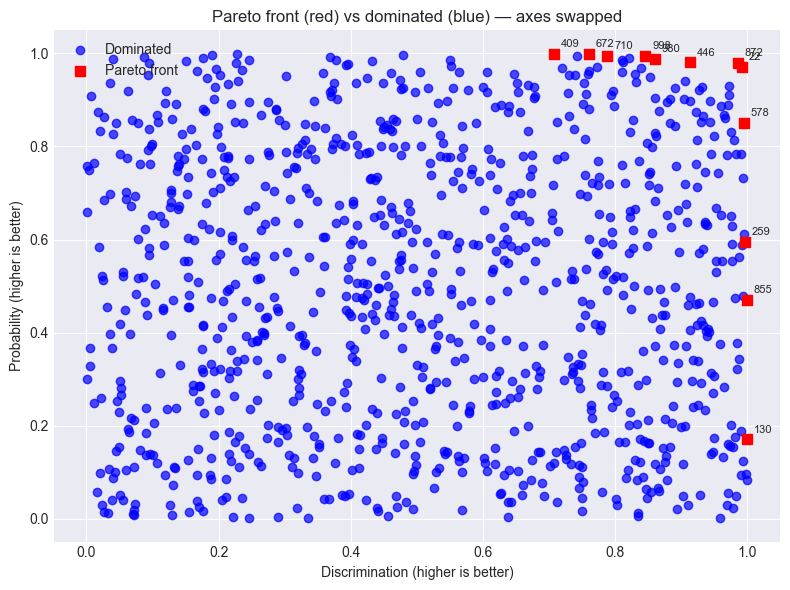

Pareto indices: [22, 130, 259, 409, 446, 578, 672, 710, 855, 872, 980, 998]


In [73]:
# Visualize Pareto front using SelectionStrategy.pareto_front
import numpy as np
import matplotlib.pyplot as plt
import common.coevolution.selection as selection

# Reproducible random example
rng = np.random.default_rng(42)
n_points = 1000
probs = rng.uniform(0.0, 1.0, size=n_points)
discs = rng.uniform(0.0, 1.0, size=n_points)

# Compute Pareto front indices
pareto_indices = selection.SelectionStrategy.pareto_front(probs, discs)
pareto_mask = np.zeros(n_points, dtype=bool)
pareto_mask[pareto_indices] = True

# Plot
plt.style.use('seaborn-v0_8-darkgrid')
# Plot with x = discs and y = probs (axes swapped)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(discs[~pareto_mask], probs[~pareto_mask], c='blue', label='Dominated', alpha=0.7)
ax.scatter(discs[pareto_mask], probs[pareto_mask], c='red', marker='s', s=60, label='Pareto front')

ax.set_xlabel('Discrimination (higher is better)')
ax.set_ylabel('Probability (higher is better)')
ax.set_title('Pareto front (red) vs dominated (blue) — axes swapped')
ax.legend()

for i in pareto_indices:
    ax.annotate(str(i), (discs[i], probs[i]), textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.show()


print('Pareto indices:', pareto_indices)